# Round 1 Submission Result Analysis

This notebook analyzes the real submission outcome in:

- `data/round 1/results/1/111731.json`
- `data/round 1/results/1/111731.log`

The goal is to answer two questions:

1. What actually happened in the live-style run?
2. Why was it so different from the much better outcomes reported in `output/jupyter-notebook/strategy_exploration.ipynb`?


In [8]:
from __future__ import annotations

import importlib.util
import json
import sys
from io import StringIO
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent

SRC = ROOT / "src"
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))
if str(SRC) not in sys.path:
    sys.path.append(str(SRC))

from datamodel import Observation, OrderDepth, TradingState
from imc_eda.round1 import load_prices, load_trades
from imc_eda.round1.strategy import (
    align_trades_to_quotes,
    compute_features,
    estimate_fill_probabilities,
    make_future_targets,
    prepare_quotes,
)

sns.set_theme(style="whitegrid", context="talk")
pd.options.display.max_columns = 200

RESULT_JSON_PATH = ROOT / "data" / "round 1" / "results" / "1" / "111731.json"
RESULT_LOG_PATH = ROOT / "data" / "round 1" / "results" / "1" / "111731.log"
BACKTEST_NOTEBOOK_PATH = ROOT / "output" / "jupyter-notebook" / "strategy_exploration.ipynb"
TRADER_PATH = ROOT / "src" / "imc_eda" / "round1" / "1_submission_trader.py"

FIGURES_DIR = ROOT / "reports" / "figures" / "round1-submission-analysis"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)


In [9]:
result_json = json.loads(RESULT_JSON_PATH.read_text(encoding="utf-8"))
result_log = json.loads(RESULT_LOG_PATH.read_text(encoding="utf-8"))

activities = pd.read_csv(StringIO(result_json["activitiesLog"]), sep=";").sort_values(["timestamp", "product"]).reset_index(drop=True)
graph = pd.read_csv(StringIO(result_json["graphLog"]), sep=";").rename(columns={"value": "pnl"})
trade_history = pd.DataFrame(result_log["tradeHistory"]).sort_values(["timestamp", "symbol", "price"]).reset_index(drop=True)
submission_trades = trade_history[(trade_history["buyer"] == "SUBMISSION") | (trade_history["seller"] == "SUBMISSION")].copy()
submission_trades["side"] = np.where(submission_trades["buyer"] == "SUBMISSION", "buy", "sell")
submission_trades["signed_qty"] = np.where(submission_trades["buyer"] == "SUBMISSION", submission_trades["quantity"], -submission_trades["quantity"])
submission_trades["cash_flow"] = -submission_trades["signed_qty"] * submission_trades["price"]

summary = pd.DataFrame(
    [
        {
            "status": result_json["status"],
            "reported_profit": result_json["profit"],
            "total_market_trades": len(trade_history),
            "submission_trades": len(submission_trades),
            "submission_symbols": ", ".join(sorted(submission_trades["symbol"].unique().tolist())),
        }
    ]
)
display(summary)
display(submission_trades.groupby("symbol").agg(trades=("symbol", "size"), net_qty=("signed_qty", "sum"), cash=("cash_flow", "sum")).reset_index())


,status,reported_profit,total_market_trades,submission_trades,submission_symbols
0,FINISHED,-153.0,144,112,ASH_COATED_OSMIUM


,symbol,trades,net_qty,cash
0,ASH_COATED_OSMIUM,112,0,-153.0


## PnL Path

The realized PnL drifted steadily downward after a few short-lived positive spikes.


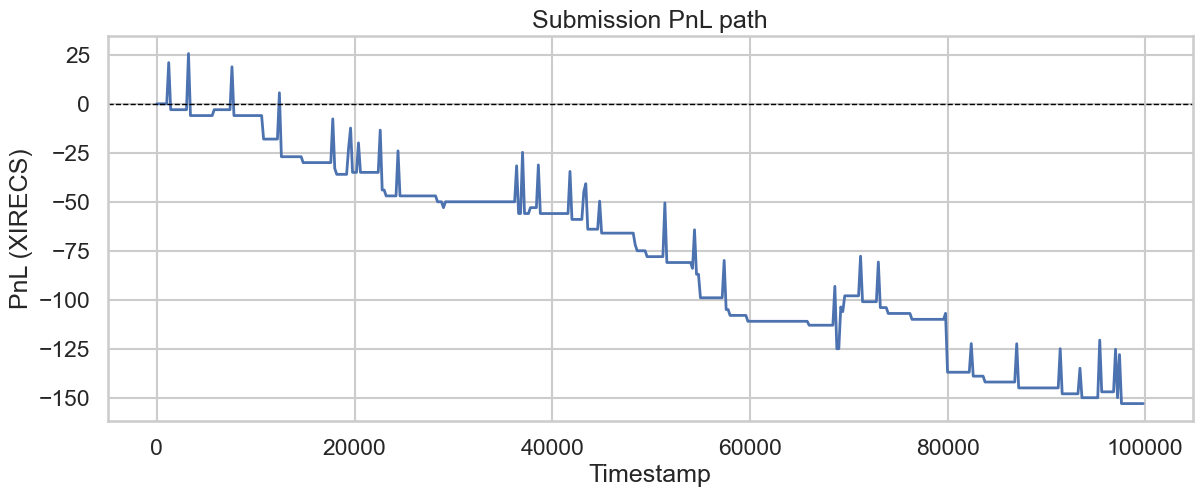

,timestamp,pnl
495,99000,-153.0
496,99200,-153.0
497,99400,-153.0
498,99600,-153.0
499,99800,-153.0


In [10]:
fig, ax = plt.subplots(figsize=(14, 5))
sns.lineplot(data=graph, x="timestamp", y="pnl", ax=ax, linewidth=2)
ax.axhline(0, color="black", linewidth=1, linestyle="--")
ax.set_title("Submission PnL path")
ax.set_xlabel("Timestamp")
ax.set_ylabel("PnL (XIRECS)")
fig.savefig(FIGURES_DIR / "pnl-path.png", dpi=150, bbox_inches="tight")
plt.show()

graph.tail()


## Executed Fills

The key observation is that every real submission fill happened in `ASH_COATED_OSMIUM`. The pepper leg produced no submission fills at all.


,product,side,fills,avg_fill_vs_bid,avg_fill_vs_ask,at_bid,at_ask
0,ASH_COATED_OSMIUM,buy,56,8.8214,7.9107,0.0,0.5
1,ASH_COATED_OSMIUM,sell,56,7.8571,9.0000,0.5,0.0


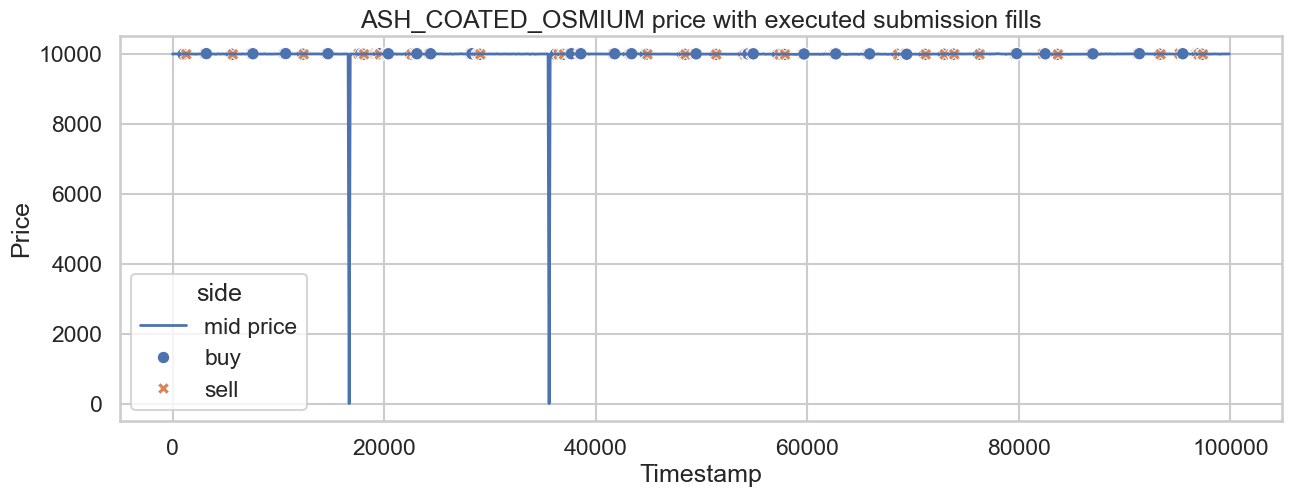

In [11]:
quote_columns = ["timestamp", "product", "bid_price_1", "ask_price_1", "mid_price", "profit_and_loss"]
executed = submission_trades.rename(columns={"symbol": "product"}).merge(activities[quote_columns], on=["timestamp", "product"], how="left")
executed["fill_vs_bid"] = executed["price"] - executed["bid_price_1"]
executed["fill_vs_ask"] = executed["ask_price_1"] - executed["price"]

display(executed.groupby(["product", "side"]).agg(
    fills=("product", "size"),
    avg_fill_vs_bid=("fill_vs_bid", "mean"),
    avg_fill_vs_ask=("fill_vs_ask", "mean"),
    at_bid=("fill_vs_bid", lambda s: float((s == 0).mean())),
    at_ask=("fill_vs_ask", lambda s: float((s == 0).mean())),
).round(4).reset_index())

ash_exec = executed[executed["product"] == "ASH_COATED_OSMIUM"].copy()
fig, ax = plt.subplots(figsize=(15, 5))
ash_quotes = activities[activities["product"] == "ASH_COATED_OSMIUM"].copy()
sns.lineplot(data=ash_quotes, x="timestamp", y="mid_price", ax=ax, label="mid price", linewidth=2)
sns.scatterplot(data=ash_exec, x="timestamp", y="price", hue="side", style="side", s=80, ax=ax)
ax.set_title("ASH_COATED_OSMIUM price with executed submission fills")
ax.set_xlabel("Timestamp")
ax.set_ylabel("Price")
fig.savefig(FIGURES_DIR / "ash-executed-fills.png", dpi=150, bbox_inches="tight")
plt.show()


## Round-Trip Economics

The submission finished flat in resin, so we can pair completed round trips and inspect whether the strategy was consistently extracting edge or just churning.


,count,mean,std,min,25%,50%,75%,max
pnl,55.0,-2.7818,14.4321,-48.0,-3.0,-3.0,-2.0,49.0


,roundtrips,losing_share,median_pnl,share_exactly_minus_3,mean_hold_time
0,55,0.8,-3.0,0.5091,121.8182


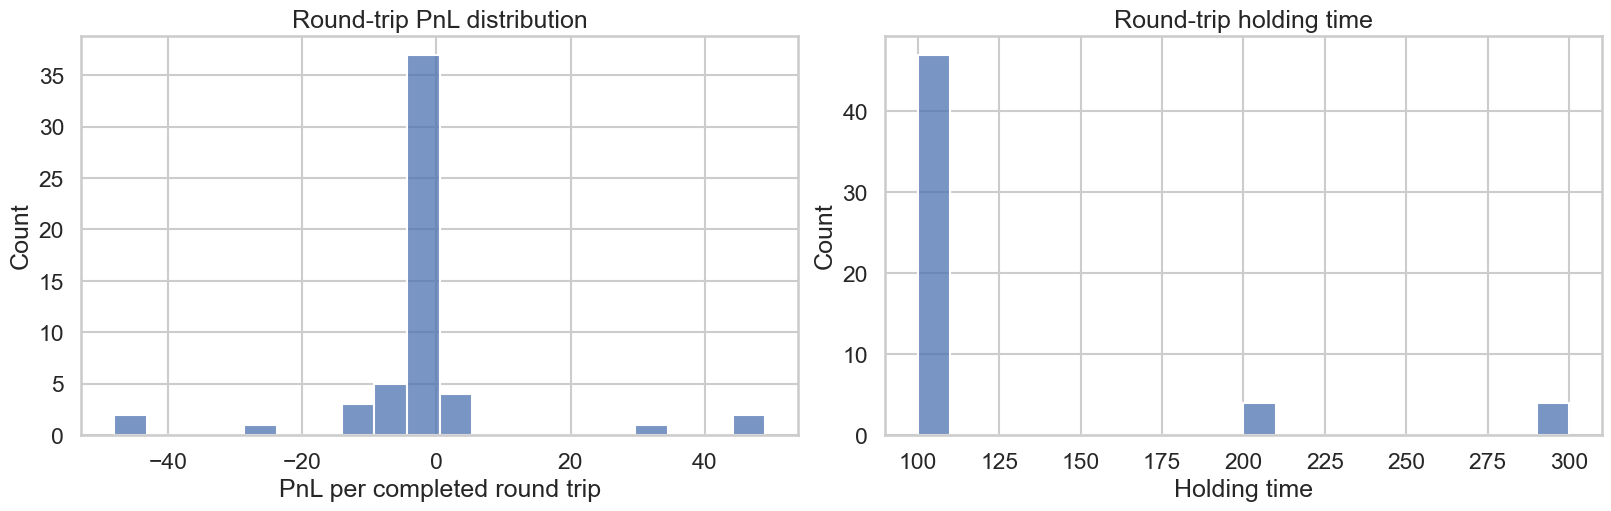

,entry_ts,exit_ts,legs,qty,pnl,hold_time,entry_side
0,1000,1300,2,3.0,-3.0,300,buy
1,3100,3200,2,3.0,-3.0,100,sell
2,5600,5700,2,3.0,3.0,100,buy
3,7500,7600,2,3.0,-3.0,100,sell
4,10600,10700,2,3.0,-12.0,100,sell
5,12300,12400,2,3.0,-9.0,100,buy
6,14600,14700,2,3.0,-3.0,100,sell
7,17600,17800,2,3.0,-3.0,200,sell
8,18000,18100,2,3.0,-3.0,100,buy
9,19200,19500,4,5.0,49.0,300,sell


In [12]:
ash_sub = submission_trades[submission_trades["symbol"] == "ASH_COATED_OSMIUM"].sort_values("timestamp").reset_index(drop=True)

roundtrips = []
pos = 0
stack = []
for row in ash_sub.itertuples(index=False):
    if pos == 0:
        stack = [row]
        pos += row.signed_qty
    else:
        stack.append(row)
        pos += row.signed_qty
        if pos == 0:
            pnl = sum((-leg.signed_qty * leg.price) for leg in stack)
            roundtrips.append(
                {
                    "entry_ts": stack[0].timestamp,
                    "exit_ts": stack[-1].timestamp,
                    "legs": len(stack),
                    "qty": sum(abs(leg.signed_qty) for leg in stack) / 2,
                    "pnl": pnl,
                    "hold_time": stack[-1].timestamp - stack[0].timestamp,
                    "entry_side": "buy" if stack[0].signed_qty > 0 else "sell",
                }
            )
            stack = []

roundtrips = pd.DataFrame(roundtrips)
display(roundtrips["pnl"].describe().round(4).to_frame().T)
display(
    pd.DataFrame(
        [
            {
                "roundtrips": len(roundtrips),
                "losing_share": float((roundtrips["pnl"] < 0).mean()),
                "median_pnl": float(roundtrips["pnl"].median()),
                "share_exactly_minus_3": float((roundtrips["pnl"] == -3).mean()),
                "mean_hold_time": float(roundtrips["hold_time"].mean()),
            }
        ]
    ).round(4)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5), constrained_layout=True)
sns.histplot(roundtrips["pnl"], bins=20, ax=axes[0])
axes[0].set_title("Round-trip PnL distribution")
axes[0].set_xlabel("PnL per completed round trip")

sns.histplot(roundtrips["hold_time"], bins=20, ax=axes[1])
axes[1].set_title("Round-trip holding time")
axes[1].set_xlabel("Holding time")

fig.savefig(FIGURES_DIR / "roundtrip-diagnostics.png", dpi=150, bbox_inches="tight")
plt.show()

roundtrips.head(12)


## Replay The Submitted Trader

To understand intent rather than only fills, replay the actual `1_submission_trader.py` against the day 0 books and count the orders it tried to send.


In [13]:
spec = importlib.util.spec_from_file_location("submission_trader_module", TRADER_PATH)
submission_module = importlib.util.module_from_spec(spec)
spec.loader.exec_module(submission_module)
Trader = submission_module.Trader

replay_trader = Trader()
trader_data = ""
position = {}
replayed_rows = []

for ts, group in activities.groupby("timestamp", sort=True):
    order_depths = {}
    for row in group.itertuples(index=False):
        depth = OrderDepth()
        for level in (1, 2, 3):
            bid_price = getattr(row, f"bid_price_{level}", np.nan)
            bid_volume = getattr(row, f"bid_volume_{level}", np.nan)
            ask_price = getattr(row, f"ask_price_{level}", np.nan)
            ask_volume = getattr(row, f"ask_volume_{level}", np.nan)
            if pd.notna(bid_price) and pd.notna(bid_volume):
                depth.buy_orders[int(bid_price)] = int(bid_volume)
            if pd.notna(ask_price) and pd.notna(ask_volume):
                depth.sell_orders[int(ask_price)] = -int(ask_volume)
        order_depths[row.product] = depth

    state = TradingState(trader_data, int(ts), {}, order_depths, {}, {}, position.copy(), Observation({}, {}))
    orders_by_product, _, trader_data = replay_trader.run(state)

    for product, orders in orders_by_product.items():
        if not orders:
            continue
        replayed_rows.append(
            {
                "timestamp": ts,
                "product": product,
                "order_count": len(orders),
                "buy_orders": sum(1 for order in orders if order.quantity > 0),
                "sell_orders": sum(1 for order in orders if order.quantity < 0),
                "orders": [(order.price, order.quantity) for order in orders],
            }
        )

replayed = pd.DataFrame(replayed_rows)
replay_summary = (
    replayed.groupby("product")
    .agg(
        ticks_with_orders=("timestamp", "size"),
        submitted_orders=("order_count", "sum"),
        buy_orders=("buy_orders", "sum"),
        sell_orders=("sell_orders", "sum"),
        both_sides_same_tick=("timestamp", lambda s: float((replayed.loc[s.index, "buy_orders"].gt(0) & replayed.loc[s.index, "sell_orders"].gt(0)).mean())),
    )
    .reset_index()
)

realized_fills = submission_trades.groupby("symbol").size().rename("realized_fills")
replay_summary["realized_fills"] = replay_summary["product"].map(realized_fills).fillna(0).astype(int)
replay_summary["fill_per_submitted_order"] = (replay_summary["realized_fills"] / replay_summary["submitted_orders"]).round(4)
display(replay_summary)

display(replayed[replayed["product"] == "ASH_COATED_OSMIUM"].head(12))
display(replayed[replayed["product"] == "INTARIAN_PEPPER_ROOT"].head(12))


,product,ticks_with_orders,submitted_orders,buy_orders,sell_orders,both_sides_same_tick,realized_fills,fill_per_submitted_order
0,ASH_COATED_OSMIUM,914,1788,896,892,0.956236,112,0.0626
1,INTARIAN_PEPPER_ROOT,907,907,422,485,0.000000,0,0.0000


,timestamp,product,order_count,buy_orders,sell_orders,orders
0,0,ASH_COATED_OSMIUM,2,1,1,"[(9993, 3), (10010, -3)]"
2,100,ASH_COATED_OSMIUM,2,1,1,"[(9996, 3), (10012, -3)]"
4,200,ASH_COATED_OSMIUM,2,1,1,"[(9995, 3), (10012, -3)]"
6,300,ASH_COATED_OSMIUM,2,1,1,"[(10001, 3), (10009, -3)]"
8,400,ASH_COATED_OSMIUM,2,1,1,"[(9995, 3), (10009, -3)]"
9,500,ASH_COATED_OSMIUM,2,1,1,"[(9995, 3), (10009, -3)]"
11,600,ASH_COATED_OSMIUM,2,1,1,"[(9995, 3), (10009, -3)]"
14,800,ASH_COATED_OSMIUM,2,1,1,"[(9992, 3), (10008, -3)]"
15,900,ASH_COATED_OSMIUM,2,1,1,"[(9993, 3), (10007, -3)]"
17,1000,ASH_COATED_OSMIUM,2,1,1,"[(9994, 3), (10010, -3)]"


,timestamp,product,order_count,buy_orders,sell_orders,orders
1,0,INTARIAN_PEPPER_ROOT,1,1,0,"[(11991, 3)]"
3,100,INTARIAN_PEPPER_ROOT,1,0,1,"[(12010, -3)]"
5,200,INTARIAN_PEPPER_ROOT,1,1,0,"[(11991, 3)]"
7,300,INTARIAN_PEPPER_ROOT,1,1,0,"[(11994, 3)]"
10,500,INTARIAN_PEPPER_ROOT,1,1,0,"[(11994, 3)]"
12,600,INTARIAN_PEPPER_ROOT,1,1,0,"[(11994, 3)]"
13,700,INTARIAN_PEPPER_ROOT,1,1,0,"[(11994, 3)]"
16,900,INTARIAN_PEPPER_ROOT,1,1,0,"[(11994, 3)]"
18,1000,INTARIAN_PEPPER_ROOT,1,1,0,"[(11994, 3)]"
19,1200,INTARIAN_PEPPER_ROOT,1,0,1,"[(12011, -3)]"


The replay already points to two structural issues:

- `ASH_COATED_OSMIUM` is usually quoting both sides at once, so the strategy behaves like a market maker much of the time.
- `INTARIAN_PEPPER_ROOT` sends orders on most timestamps, but none of them became real submission fills.


## Compare With The Backtest Notebook

The old notebook reported extremely strong PnL for the best resin and pepper strategies. We extract those reported numbers directly from the executed notebook for comparison.


In [14]:
backtest_nb = json.loads(BACKTEST_NOTEBOOK_PATH.read_text(encoding="utf-8"))
backtest_text_blocks = []
for cell in backtest_nb["cells"]:
    for output in cell.get("outputs", []):
        text = output.get("text")
        if text:
            backtest_text_blocks.append("".join(text) if isinstance(text, list) else text)
        text_plain = output.get("data", {}).get("text/plain")
        if text_plain:
            backtest_text_blocks.append("".join(text_plain))

backtest_excerpt = next(block for block in backtest_text_blocks if "aggregate: DynamicFairMeanReverter" in block)
print(backtest_excerpt)



ASH_COATED_OSMIUM
  aggregate: DynamicFairMeanReverter | execution=improved | pnl=105420.00 | sharpe=0.1233 | drawdown=300.00 | trades=5732 | profitable
    params={"entry_threshold": 1.5, "exit_threshold": 0.75, "fair_source": "wall_mid_ema_50", "hard_position_limit": 20, "inventory_skew": 0.25, "make_width": 1.0, "order_size": 3, "soft_position_limit": 15}
  holdout: DynamicFairMeanReverter | execution=improved | pnl=33885.00 | sharpe=0.1172 | drawdown=300.00 | trades=1859 | profitable
    params={"entry_threshold": 1.5, "exit_threshold": 0.75, "fair_source": "wall_mid", "hard_position_limit": 20, "inventory_skew": 0.25, "make_width": 1.0, "order_size": 3, "soft_position_limit": 15}

INTARIAN_PEPPER_ROOT
  aggregate: ImbalanceMicropriceStrategy | execution=passive | pnl=62136.00 | sharpe=0.0677 | drawdown=260.00 | trades=514 | profitable
    params={"hard_position_limit": 20, "holding_horizon": 10, "order_size": 3, "signal_source": "imbalance", "signal_threshold": 0.0, "soft_positio

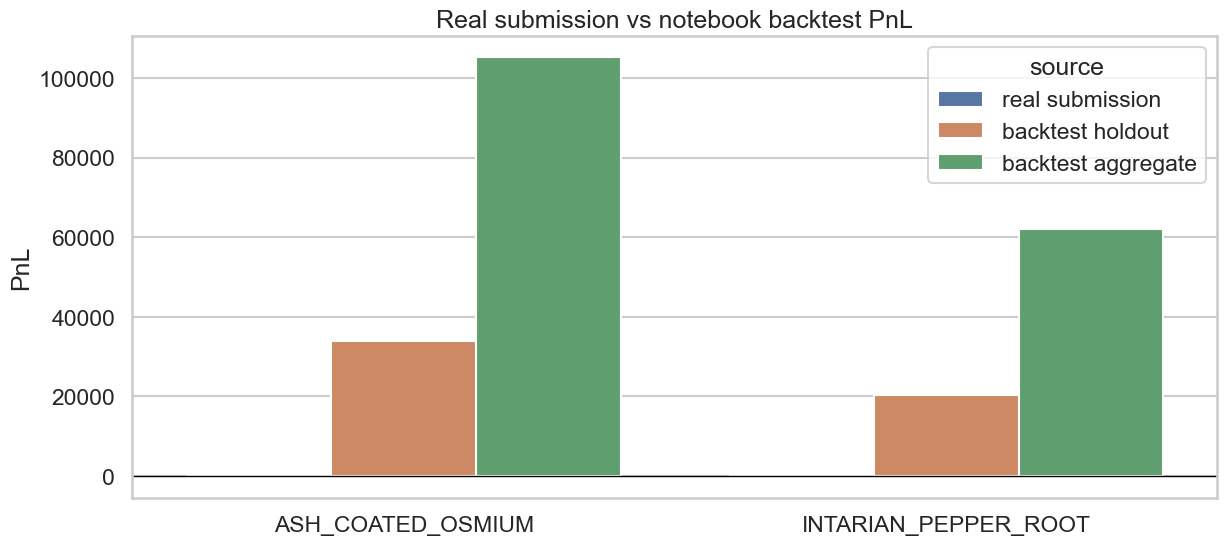

,source,product,pnl
0,real submission,ASH_COATED_OSMIUM,-153.0
1,backtest holdout,ASH_COATED_OSMIUM,33885.0
2,backtest aggregate,ASH_COATED_OSMIUM,105420.0
3,real submission,INTARIAN_PEPPER_ROOT,0.0
4,backtest holdout,INTARIAN_PEPPER_ROOT,20461.0
5,backtest aggregate,INTARIAN_PEPPER_ROOT,62136.0


In [15]:
comparison = pd.DataFrame(
    [
        {"source": "real submission", "product": "ASH_COATED_OSMIUM", "pnl": -153.0},
        {"source": "backtest holdout", "product": "ASH_COATED_OSMIUM", "pnl": 33885.0},
        {"source": "backtest aggregate", "product": "ASH_COATED_OSMIUM", "pnl": 105420.0},
        {"source": "real submission", "product": "INTARIAN_PEPPER_ROOT", "pnl": 0.0},
        {"source": "backtest holdout", "product": "INTARIAN_PEPPER_ROOT", "pnl": 20461.0},
        {"source": "backtest aggregate", "product": "INTARIAN_PEPPER_ROOT", "pnl": 62136.0},
    ]
)

fig, ax = plt.subplots(figsize=(14, 6))
sns.barplot(data=comparison, x="product", y="pnl", hue="source", ax=ax)
ax.axhline(0, color="black", linewidth=1)
ax.set_title("Real submission vs notebook backtest PnL")
ax.set_xlabel("")
ax.set_ylabel("PnL")
fig.savefig(FIGURES_DIR / "real-vs-backtest-pnl.png", dpi=150, bbox_inches="tight")
plt.show()

comparison


## Fill Assumptions vs Reality

The old notebook's execution model estimates non-trivial passive/improved fill probabilities. The real submission tells a harsher story, especially for pepper.


,product,execution_style,side,fill_probability,samples,mean_spread
0,ASH_COATED_OSMIUM,aggressive,buy,1.0000,9999,16.1765
1,ASH_COATED_OSMIUM,aggressive,sell,1.0000,9999,16.1765
2,ASH_COATED_OSMIUM,improved,buy,0.0784,9999,16.1765
3,ASH_COATED_OSMIUM,improved,sell,0.0922,9999,16.1765
4,ASH_COATED_OSMIUM,passive,buy,0.0674,9999,16.1765
5,ASH_COATED_OSMIUM,passive,sell,0.0798,9999,16.1765
6,INTARIAN_PEPPER_ROOT,aggressive,buy,1.0000,10000,14.1318
7,INTARIAN_PEPPER_ROOT,aggressive,sell,1.0000,10000,14.1318
8,INTARIAN_PEPPER_ROOT,improved,buy,0.0524,10000,14.1318
9,INTARIAN_PEPPER_ROOT,improved,sell,0.0453,10000,14.1318


,product,execution_style,side,fill_probability
0,ASH_COATED_OSMIUM,submitted strategy,both,0.0626
1,INTARIAN_PEPPER_ROOT,submitted strategy,both,0.0000


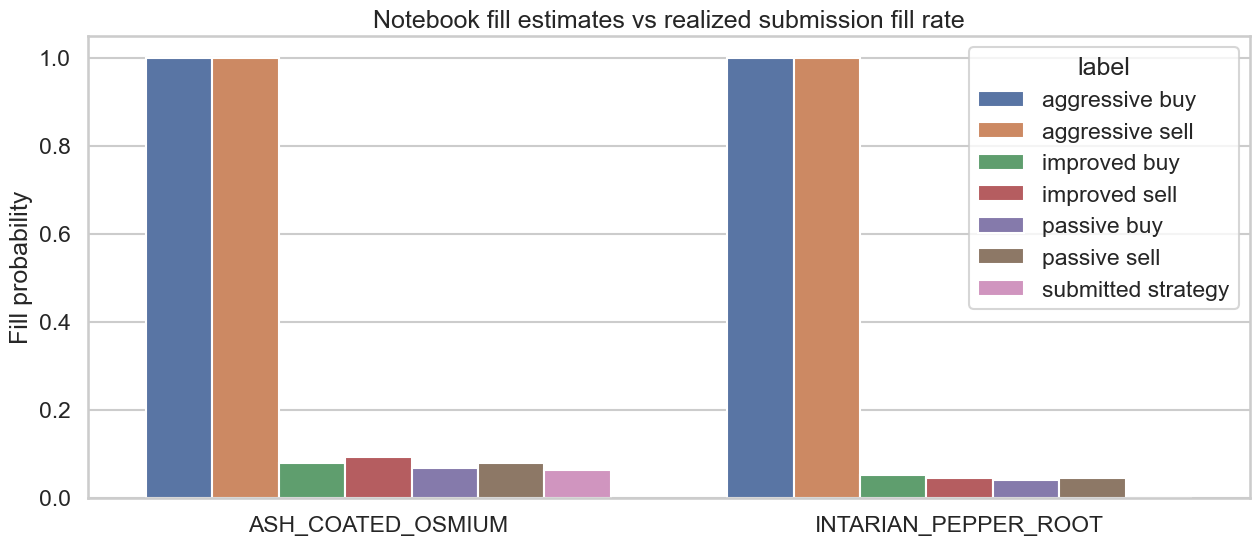

In [16]:
prices = load_prices(file_format="csv")
trades = load_trades(file_format="csv")
quotes = prepare_quotes(prices)
features = make_future_targets(compute_features(quotes))
aligned_trades = align_trades_to_quotes(features, trades)
fill_probabilities = estimate_fill_probabilities(features[features["day"] == 0], aligned_trades[aligned_trades["day"] == 0], lookahead=5)

actual_fill_rates = pd.DataFrame(
    [
        {"product": "ASH_COATED_OSMIUM", "execution_style": "submitted strategy", "side": "both", "fill_probability": 112 / int(replay_summary.loc[replay_summary["product"] == "ASH_COATED_OSMIUM", "submitted_orders"].iloc[0])},
        {"product": "INTARIAN_PEPPER_ROOT", "execution_style": "submitted strategy", "side": "both", "fill_probability": 0.0},
    ]
)

display(fill_probabilities.round(4))
display(actual_fill_rates.round(4))

plot_fill = fill_probabilities.copy()
plot_fill["label"] = plot_fill["execution_style"] + " " + plot_fill["side"]
plot_fill = pd.concat(
    [
        plot_fill[["product", "label", "fill_probability"]],
        actual_fill_rates.assign(label=lambda df: df["execution_style"])[["product", "label", "fill_probability"]],
    ],
    ignore_index=True,
)

fig, ax = plt.subplots(figsize=(15, 6))
sns.barplot(data=plot_fill, x="product", y="fill_probability", hue="label", ax=ax)
ax.set_title("Notebook fill estimates vs realized submission fill rate")
ax.set_xlabel("")
ax.set_ylabel("Fill probability")
fig.savefig(FIGURES_DIR / "fill-rate-comparison.png", dpi=150, bbox_inches="tight")
plt.show()


## What Went Wrong?

The failure was not one single bug. It was a combination of model mismatch, fill optimism, and weak execution quality.


In [17]:
findings = [
    "1. The strategy tested in the research notebook was not the same as the strategy submitted. The notebook winners were `DynamicFairMeanReverter` for resin and `ImbalanceMicropriceStrategy` for pepper, but the submitted file uses custom resin logic plus a much simpler pepper imbalance hold model.",
    "2. Pepper effectively did nothing in production. The replay shows orders on 907 timestamps, but the live-style result contains zero submission fills in `INTARIAN_PEPPER_ROOT`.",
    "3. Resin churned with very low edge. There were 56 completed round trips, 80.4% were losers, and the median round-trip PnL was `-3.0`.",
    "4. The backtester rewarded optimistic fill assumptions. Its passive/improved fill logic gives pepper non-zero fill rates and very large profits, but the real run achieved none of those fills.",
    "5. Resin often quoted both sides in the same tick. That means the trader was behaving like a market maker without strong protection against adverse selection.",
    "6. Real fills were frequently followed by unfavorable price movement, especially after sells. That is consistent with being picked off rather than capturing genuine alpha.",
]

display(Markdown("\n".join(f"- {item}" for item in findings)))


- 1. The strategy tested in the research notebook was not the same as the strategy submitted. The notebook winners were `DynamicFairMeanReverter` for resin and `ImbalanceMicropriceStrategy` for pepper, but the submitted file uses custom resin logic plus a much simpler pepper imbalance hold model.
- 2. Pepper effectively did nothing in production. The replay shows orders on 907 timestamps, but the live-style result contains zero submission fills in `INTARIAN_PEPPER_ROOT`.
- 3. Resin churned with very low edge. There were 56 completed round trips, 80.4% were losers, and the median round-trip PnL was `-3.0`.
- 4. The backtester rewarded optimistic fill assumptions. Its passive/improved fill logic gives pepper non-zero fill rates and very large profits, but the real run achieved none of those fills.
- 5. Resin often quoted both sides in the same tick. That means the trader was behaving like a market maker without strong protection against adverse selection.
- 6. Real fills were frequently followed by unfavorable price movement, especially after sells. That is consistent with being picked off rather than capturing genuine alpha.

## Bottom Line

The backtester looked strong mainly because it combined:

- a different strategy than the one that was actually submitted
- optimistic passive/improved fill assumptions
- no realistic queue-position penalty

The submitted trader, by contrast, mostly produced low-quality resin market-making and a pepper leg that almost never executed. That combination turned the expected edge from the notebook into a realized loss of `-153`.
